In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../Dataset/loan_data.csv")
df.head()

,Customer_ID,Gender,Marital_Status,Number_of_Dependents,Education,Loan_Status,Annual_Income,Credit_Score,Loan_Amount,Term,Property_Area,Loan_Approval
0,LP216038,Female,No,2,Graduate,No,4809.0,3329.0,3650.0,180,Rural,Yes
1,LP288956,Female,Yes,1,Graduate,No,3358.0,NaN,6680.0,360,Rural,No
2,LP153364,Female,Yes,1,Graduate,No,9873.0,1649.0,NaN,360,Semiurban,No
3,LP945891,Male,No,0,Graduate,Yes,11665.0,4378.0,8366.0,360,Rural,Yes
4,LP425056,Female,No,1,Graduate,No,5890.0,1523.0,8741.0,180,Urban,Yes


In [4]:
df.columns
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           10000 non-null  str    
 1   Gender                10000 non-null  str    
 2   Marital_Status        10000 non-null  str    
 3   Number_of_Dependents  10000 non-null  str    
 4   Education             10000 non-null  str    
 5   Loan_Status           10000 non-null  str    
 6   Annual_Income         9000 non-null   float64
 7   Credit_Score          8979 non-null   float64
 8   Loan_Amount           8987 non-null   float64
 9   Term                  10000 non-null  int64  
 10  Property_Area         10000 non-null  str    
 11  Loan_Approval         10000 non-null  str    
dtypes: float64(3), int64(1), str(8)
memory usage: 1.3 MB


In [5]:
df.isnull().sum()

Customer_ID                0
Gender                     0
Marital_Status             0
Number_of_Dependents       0
Education                  0
Loan_Status                0
Annual_Income           1000
Credit_Score            1021
Loan_Amount             1013
Term                       0
Property_Area              0
Loan_Approval              0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['Loan_Status'].value_counts()

Loan_Status
Yes    5007
No     4993
Name: count, dtype: int64

In [8]:
df['Annual_Income'] = df['Annual_Income'].fillna(df['Annual_Income'].median())
df['Credit_Score'] = df['Credit_Score'].fillna(df['Credit_Score'].median())
df['Loan_Amount'] = df['Loan_Amount'].fillna(df['Loan_Amount'].median())


In [9]:
df.isnull().sum()

Customer_ID             0
Gender                  0
Marital_Status          0
Number_of_Dependents    0
Education               0
Loan_Status             0
Annual_Income           0
Credit_Score            0
Loan_Amount             0
Term                    0
Property_Area           0
Loan_Approval           0
dtype: int64

In [10]:
df = df.drop("Customer_ID", axis=1)
df.head()

,Gender,Marital_Status,Number_of_Dependents,Education,Loan_Status,Annual_Income,Credit_Score,Loan_Amount,Term,Property_Area,Loan_Approval
0,Female,No,2,Graduate,No,4809.0,3329.0,3650.0,180,Rural,Yes
1,Female,Yes,1,Graduate,No,3358.0,2627.0,6680.0,360,Rural,No
2,Female,Yes,1,Graduate,No,9873.0,1649.0,5021.0,360,Semiurban,No
3,Male,No,0,Graduate,Yes,11665.0,4378.0,8366.0,360,Rural,Yes
4,Female,No,1,Graduate,No,5890.0,1523.0,8741.0,180,Urban,Yes


In [11]:
print(df["Loan_Status"].unique())
print(df["Loan_Approval"].unique())

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str


In [12]:
df["Loan_Status"].equals(df["Loan_Approval"])

False

In [13]:
(df["Loan_Status"] == df["Loan_Approval"]).value_counts()

True     5082
False    4918
Name: count, dtype: int64

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Loan_Status"] = le.fit_transform(df["Loan_Status"])
df["Loan_Approval"] = le.fit_transform(df["Loan_Approval"])
df["Marital_Status"] = le.fit_transform(df["Marital_Status"])
df["Education"] = le.fit_transform(df["Education"])
for col in ["Gender","Property_Area"]:
    df[col] = LabelEncoder().fit_transform(df[col])
df.head()

,Gender,Marital_Status,Number_of_Dependents,Education,Loan_Status,Annual_Income,Credit_Score,Loan_Amount,Term,Property_Area,Loan_Approval
0,0,0,2,0,0,4809.0,3329.0,3650.0,180,0,1
1,0,1,1,0,0,3358.0,2627.0,6680.0,360,0,0
2,0,1,1,0,0,9873.0,1649.0,5021.0,360,1,0
3,1,0,0,0,1,11665.0,4378.0,8366.0,360,0,1
4,0,0,1,0,0,5890.0,1523.0,8741.0,180,2,1


In [15]:
df.isnull().sum()
df.head()

,Gender,Marital_Status,Number_of_Dependents,Education,Loan_Status,Annual_Income,Credit_Score,Loan_Amount,Term,Property_Area,Loan_Approval
0,0,0,2,0,0,4809.0,3329.0,3650.0,180,0,1
1,0,1,1,0,0,3358.0,2627.0,6680.0,360,0,0
2,0,1,1,0,0,9873.0,1649.0,5021.0,360,1,0
3,1,0,0,0,1,11665.0,4378.0,8366.0,360,0,1
4,0,0,1,0,0,5890.0,1523.0,8741.0,180,2,1


In [16]:
df['Loan_Approval'].value_counts()

Loan_Approval
1    5061
0    4939
Name: count, dtype: int64

In [17]:
df.dtypes

Gender                    int64
Marital_Status            int64
Number_of_Dependents        str
Education                 int64
Loan_Status               int64
Annual_Income           float64
Credit_Score            float64
Loan_Amount             float64
Term                      int64
Property_Area             int64
Loan_Approval             int64
dtype: object

In [18]:
df['Number_of_Dependents'] = df['Number_of_Dependents'].replace('3+',3)

In [19]:
df['Number_of_Dependents'] = df['Number_of_Dependents'].astype(str).str.strip()
df['Number_of_Dependents'] = df['Number_of_Dependents'].replace('3+', 3)
df['Number_of_Dependents'] = pd.to_numeric(df['Number_of_Dependents'], errors='coerce')
df.dtypes
df['Number_of_Dependents'].unique()

array([2, 1, 0, 3])

In [20]:
df['Number_of_Dependents'] = df['Number_of_Dependents'].astype(str).str.strip()

df['Number_of_Dependents'] = df['Number_of_Dependents'].replace({
    '3+': 3,
    '3+ ': 3,
    ' 3+': 3
})

df['Number_of_Dependents'] = pd.to_numeric(df['Number_of_Dependents'], errors='coerce')

In [21]:
df.select_dtypes(include=object).columns

Index([], dtype='str')

In [22]:
X = df.drop('Loan_Approval',axis=1)
y = df['Loan_Approval']

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2, random_state=42
)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5075


In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[371 621]
 [364 644]]


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.37      0.43       992
           1       0.51      0.64      0.57      1008

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.50      2000
weighted avg       0.51      0.51      0.50      2000



In [29]:
from sklearn.metrics import accuracy_score, classification_report

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.4825
              precision    recall  f1-score   support

           0       0.48      0.48      0.48       992
           1       0.49      0.48      0.48      1008

    accuracy                           0.48      2000
   macro avg       0.48      0.48      0.48      2000
weighted avg       0.48      0.48      0.48      2000



In [31]:
print(y_train.value_counts())
print(y_test.value_counts())

Loan_Approval
1    4053
0    3947
Name: count, dtype: int64
Loan_Approval
1    1008
0     992
Name: count, dtype: int64


In [32]:
print(X_train.shape)
print(X_test.shape)

(8000, 10)
(2000, 10)


In [33]:
print(X.head())

   Gender  Marital_Status  Number_of_Dependents  Education  Loan_Status  \
0       0               0                     2          0            0   
1       0               1                     1          0            0   
2       0               1                     1          0            0   
3       1               0                     0          0            1   
4       0               0                     1          0            0   

   Annual_Income  Credit_Score  Loan_Amount  Term  Property_Area  
0         4809.0        3329.0       3650.0   180              0  
1         3358.0        2627.0       6680.0   360              0  
2         9873.0        1649.0       5021.0   360              1  
3        11665.0        4378.0       8366.0   360              0  
4         5890.0        1523.0       8741.0   180              2  


In [34]:
print(y_train.head())

9254    1
1561    0
1670    1
6087    1
6669    1
Name: Loan_Approval, dtype: int64


In [35]:
print(df[['Loan_Status','Loan_Approval']].head(10))

   Loan_Status  Loan_Approval
0            0              1
1            0              0
2            0              0
3            1              1
4            0              1
5            0              0
6            1              0
7            1              0
8            0              0
9            1              1


In [36]:
print(df[['Loan_Status','Loan_Approval']].value_counts())

Loan_Status  Loan_Approval
1            1                2575
0            0                2507
             1                2486
1            0                2432
Name: count, dtype: int64


In [37]:
print(df.corr()['Loan_Approval'].sort_values())

Loan_Amount            -0.013276
Term                   -0.011911
Number_of_Dependents   -0.011116
Annual_Income          -0.010512
Gender                 -0.001671
Property_Area           0.002903
Education               0.003659
Marital_Status          0.005825
Credit_Score            0.012678
Loan_Status             0.016384
Loan_Approval           1.000000
Name: Loan_Approval, dtype: float64


In [38]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import accuracy_score,classification_report
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test,dt_pred)

print("Decision Tree Accuracy:",dt_accuracy)
print(classification_report(y_test,dt_pred))

Decision Tree Accuracy: 0.4865
              precision    recall  f1-score   support

           0       0.48      0.47      0.48       992
           1       0.49      0.50      0.49      1008

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



In [39]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
y_predict = model.predict(X_test)

In [40]:
models_accuracy = {
    "Logistic Regression":accuracy_score(y_test, y_predict), 
    "Random Forest":accuracy_score(y_test, rf_pred),
    "Desicion Tree":dt_accuracy
}
print(models_accuracy)

{'Logistic Regression': 0.5075, 'Random Forest': 0.4825, 'Desicion Tree': 0.4865}


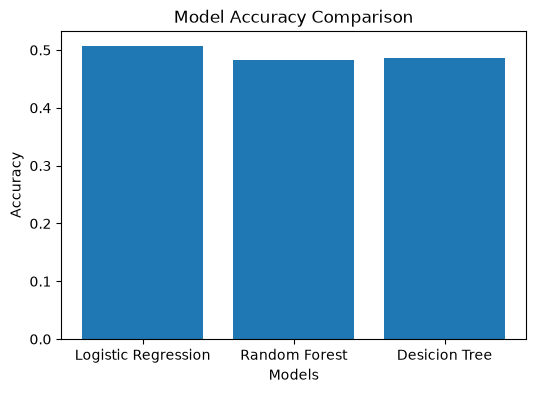

In [41]:
plt.figure(figsize=(6,4))
plt.bar(models_accuracy.keys(),models_accuracy.values())

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()


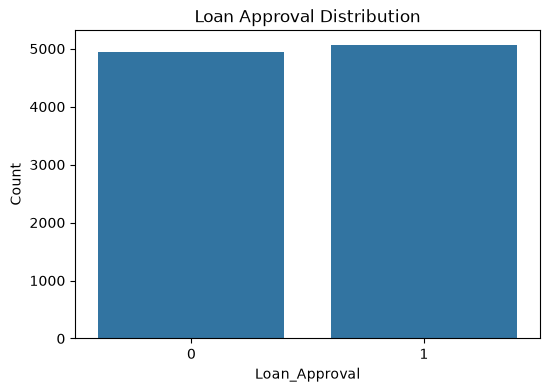

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Approval',data=df)

plt.xlabel("Loan_Approval")
plt.ylabel("Count")
plt.title("Loan Approval Distribution")

plt.show()


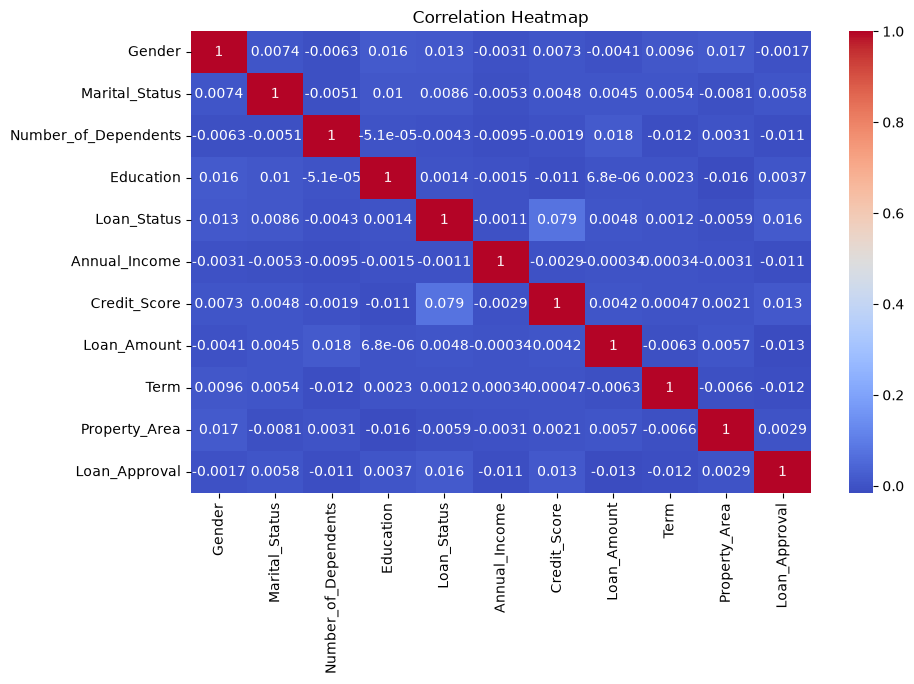

In [43]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()


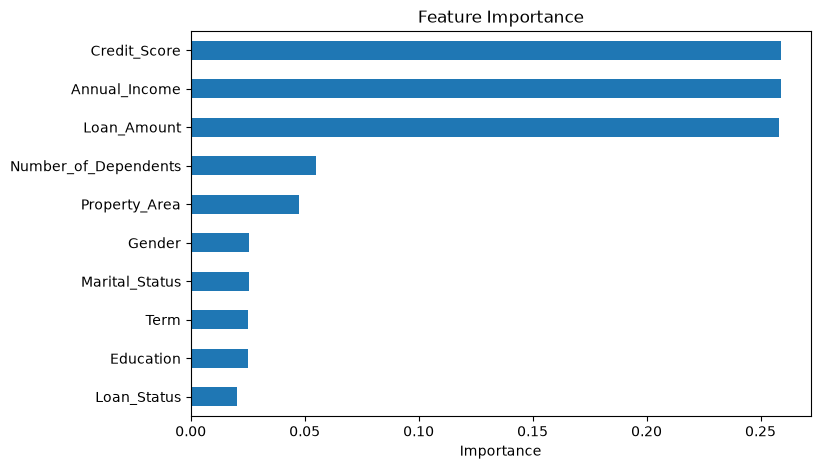

In [44]:
importance = pd.Series(rf_model.feature_importances_,
                       index=X.columns)
importance.sort_values().plot(kind='barh',figsize=(8,5))
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

In [45]:
import pickle
final_model = LogisticRegression(max_iter=1000)

final_model.fit(X_train, y_train)
pickle.dump(final_model,
            open("loan_prediction_model.pkl","wb"))
print("Model saved successfully")

Model saved successfully


In [46]:
import pickle
pickle.dump(scaler, open("scaler.pkl", "wb"))
print("scaler saved successfully")

scaler saved successfully


In [47]:
X.columns

Index(['Gender', 'Marital_Status', 'Number_of_Dependents', 'Education',
       'Loan_Status', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Term',
       'Property_Area'],
      dtype='str')

In [48]:
y.name

'Loan_Approval'

In [49]:
df.head()

,Gender,Marital_Status,Number_of_Dependents,Education,Loan_Status,Annual_Income,Credit_Score,Loan_Amount,Term,Property_Area,Loan_Approval
0,0,0,2,0,0,4809.0,3329.0,3650.0,180,0,1
1,0,1,1,0,0,3358.0,2627.0,6680.0,360,0,0
2,0,1,1,0,0,9873.0,1649.0,5021.0,360,1,0
3,1,0,0,0,1,11665.0,4378.0,8366.0,360,0,1
4,0,0,1,0,0,5890.0,1523.0,8741.0,180,2,1


In [50]:
model.predict(X.iloc[[0]])

c:\Users\sanya\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


array([0])

In [51]:
y.iloc[0]

np.int64(1)

In [52]:
accuracy_score(y_test, y_predict)

0.5075

In [53]:
y.value_counts()

Loan_Approval
1    5061
0    4939
Name: count, dtype: int64

In [54]:
X.head()

,Gender,Marital_Status,Number_of_Dependents,Education,Loan_Status,Annual_Income,Credit_Score,Loan_Amount,Term,Property_Area
0,0,0,2,0,0,4809.0,3329.0,3650.0,180,0
1,0,1,1,0,0,3358.0,2627.0,6680.0,360,0
2,0,1,1,0,0,9873.0,1649.0,5021.0,360,1
3,1,0,0,0,1,11665.0,4378.0,8366.0,360,0
4,0,0,1,0,0,5890.0,1523.0,8741.0,180,2


In [55]:
model

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
accuracy_score(y_test, rf_pred)

0.4825

In [57]:
df.corr()['Loan_Approval']

Gender                 -0.001671
Marital_Status          0.005825
Number_of_Dependents   -0.011116
Education               0.003659
Loan_Status             0.016384
Annual_Income          -0.010512
Credit_Score            0.012678
Loan_Amount            -0.013276
Term                   -0.011911
Property_Area           0.002903
Loan_Approval           1.000000
Name: Loan_Approval, dtype: float64

In [58]:
df[['Loan_Status','Loan_Approval']].value_counts()

Loan_Status  Loan_Approval
1            1                2575
0            0                2507
             1                2486
1            0                2432
Name: count, dtype: int64

In [60]:
df.shape

(10000, 11)

In [61]:
X_train.shape, X_test.shape
y_train.shape, y_test.shape

((8000,), (2000,))

In [62]:
model.score(X_train,y_train)

0.509375

In [63]:
df.dtypes

Gender                    int64
Marital_Status            int64
Number_of_Dependents      int64
Education                 int64
Loan_Status               int64
Annual_Income           float64
Credit_Score            float64
Loan_Amount             float64
Term                      int64
Property_Area             int64
Loan_Approval             int64
dtype: object

In [64]:
df['Loan_Approval'].unique()

array([1, 0])

In [65]:
df.head(10)

,Gender,Marital_Status,Number_of_Dependents,Education,Loan_Status,Annual_Income,Credit_Score,Loan_Amount,Term,Property_Area,Loan_Approval
0,0,0,2,0,0,4809.0,3329.0,3650.0,180,0,1
1,0,1,1,0,0,3358.0,2627.0,6680.0,360,0,0
2,0,1,1,0,0,9873.0,1649.0,5021.0,360,1,0
3,1,0,0,0,1,11665.0,4378.0,8366.0,360,0,1
4,0,0,1,0,0,5890.0,1523.0,8741.0,180,2,1
5,0,1,3,0,0,11757.0,4412.0,2148.0,360,1,0
6,1,0,3,0,1,11375.0,693.0,241.0,180,2,0
7,0,0,2,1,1,9673.0,3291.0,5021.0,180,0,0
8,1,1,0,0,0,7148.0,4049.0,8983.0,360,2,0
9,1,0,2,1,1,6810.0,1887.0,1176.0,180,1,1


In [66]:
X = df.drop(['Loan_Approval','Loan_Status'],axis=1)
y=df['Loan_Approval']

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [68]:
from sklearn.linear_model import  LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
pred = model.predict(X_test)

accuracy_score(y_test, pred)

0.5075